## **1. Project Title and Aim**



**Title:**  
**A Hybrid Time-Series Framework for Early Detection and Slow Drift Detection of Household Energy Inefficiency Using Smart Meter, Weather, and Carbon Intensity Data**

**Aim:**  
To develop a **multi-household time-series framework** that integrates **forecasting** and **residual-based monitoring** to detect **early inefficiency events** and **slow drift** in electricity consumption while assessing **environmental impact**.

**Objectives:**  
- To preprocess and integrate **smart meter, weather, and carbon intensity data**  
- To analyse **temporal consumption patterns** across households  
- To develop forecasting models using **TCN** and **XGBoost**  
- To detect inefficiency-related drift using **STL, CUSUM, and EWMA**  
- To enable **early anomaly detection** and **slow drift detection**  
- To evaluate **drift severity** and **model performance**  
- To analyse the **carbon impact** of excess energy consumption  
- To apply **Explainable AI (SHAP and permutation importance)**  
- To simulate **pseudo real-time monitoring** and **alert generation**  

**Observation:**  
Electricity consumption evolves over time with both **sudden changes** and **gradual behavioural shifts** influenced by **internal and external factors**.

**Interpretation:**  
A hybrid approach combining **forecasting**, **statistical monitoring**, and **explainable AI** provides a **scalable**, **interpretable**, and **real-world applicable solution** for detecting and managing household energy inefficiency.

## **2. Imports and Setup**

In [ ]:
!pip install keras-tcn -q
!pip install xgboost -q
!pip install statsmodels -q
!pip install shap -q
!pip install streamlit -q

import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_theme(style="whitegrid", context="talk")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.seasonal import STL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN

from xgboost import XGBRegressor
import shap

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## **3. Mount Google Drive and Define Paths**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
energy_glob = "/content/drive/MyDrive/Energy/LCL-June2015v2_*.csv"

tg_path = "/content/drive/MyDrive/Weather/TG_STAID001860.txt"
tx_path = "/content/drive/MyDrive/Weather/TX_STAID001860.txt"
tn_path = "/content/drive/MyDrive/Weather/TN_STAID001860.txt"

carbon_path = "/content/drive/MyDrive/Carbon Intensity Dataset.csv"

## **4. Load and Merge Electricity Files**

In [ ]:
def extract_number(filename: str) -> int:
    match = re.search(r'_(\d+)\.csv$', filename)
    return int(match.group(1)) if match else -1

energy_files = glob.glob(energy_glob)
energy_files_sorted = sorted(energy_files, key=extract_number)

print("Total energy files found:", len(energy_files_sorted))
print("Example files:", energy_files_sorted[:3])

Total energy files found: 168
Example files: ['/content/drive/MyDrive/Energy/LCL-June2015v2_0.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_1.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_2.csv']


### **4.1 Choose Number of Files**

In [ ]:
N_FILES = 50
files_to_use = energy_files_sorted[:N_FILES]
print("Number of selected files:", len(files_to_use))

Number of selected files: 50


In [ ]:
energy_parts = []

for fp in files_to_use:
    temp_df = pd.read_csv(fp, low_memory=False)
    temp_df["source_file"] = os.path.basename(fp)
    energy_parts.append(temp_df)

energy_raw = pd.concat(energy_parts, ignore_index=True)
energy_raw.columns = energy_raw.columns.str.strip().str.lower()

print("Combined shape:", energy_raw.shape)
energy_raw.head()

Combined shape: (50000000, 5)


,lclid,stdortou,datetime,kwh/hh (per half hour),source_file
0,MAC000002,Std,2012-10-12 00:30:00.0000000,0,LCL-June2015v2_0.csv
1,MAC000002,Std,2012-10-12 01:00:00.0000000,0,LCL-June2015v2_0.csv
2,MAC000002,Std,2012-10-12 01:30:00.0000000,0,LCL-June2015v2_0.csv
3,MAC000002,Std,2012-10-12 02:00:00.0000000,0,LCL-June2015v2_0.csv
4,MAC000002,Std,2012-10-12 02:30:00.0000000,0,LCL-June2015v2_0.csv


## **5. Clean Electricity Data**

In [ ]:
energy_raw = energy_raw.rename(columns={
    "lclid": "LCLid",
    "stdortou": "stdorToU",
    "kwh/hh (per half hour)": "kwh_hh"
})

energy_raw["datetime"] = pd.to_datetime(energy_raw["datetime"], errors="coerce")
energy_raw["kwh_hh"] = pd.to_numeric(energy_raw["kwh_hh"], errors="coerce")

energy_raw = energy_raw.dropna(subset=["LCLid", "datetime", "kwh_hh"])
energy_raw["date"] = energy_raw["datetime"].dt.normalize()

print("Cleaned shape:", energy_raw.shape)
print(energy_raw.isna().sum())
energy_raw.head()

Cleaned shape: (49998412, 6)
LCLid          0
stdorToU       0
datetime       0
kwh_hh         0
source_file    0
date           0
dtype: int64


,LCLid,stdorToU,datetime,kwh_hh,source_file,date
0,MAC000002,Std,2012-10-12 00:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
1,MAC000002,Std,2012-10-12 01:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
2,MAC000002,Std,2012-10-12 01:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
3,MAC000002,Std,2012-10-12 02:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
4,MAC000002,Std,2012-10-12 02:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12


## **6. Aggregate to Daily Household Consumption**

In [ ]:
energy_daily = (
    energy_raw.groupby(["LCLid", "date"], as_index=False)["kwh_hh"]
    .sum()
    .rename(columns={"kwh_hh": "daily_kWh"})
)

energy_daily["daily_kWh_log"] = np.log1p(energy_daily["daily_kWh"])

print("Daily shape:", energy_daily.shape)
print("Households:", energy_daily["LCLid"].nunique())
print("Date range:", energy_daily["date"].min(), "to", energy_daily["date"].max())

energy_daily.head()

Daily shape: (1045743, 4)
Households: 1587
Date range: 2011-11-23 00:00:00 to 2014-02-28 00:00:00


,LCLid,date,daily_kWh,daily_kWh_log
0,MAC000002,2012-10-12,7.098,2.092
1,MAC000002,2012-10-13,11.087,2.492
2,MAC000002,2012-10-14,13.223,2.655
3,MAC000002,2012-10-15,10.257,2.421
4,MAC000002,2012-10-16,9.769,2.377


## **7. Household Coverage Analysis**

In [ ]:
df_cov = energy_daily.copy()
df_cov = df_cov.sort_values(["LCLid", "date"]).reset_index(drop=True)

coverage = df_cov.groupby("LCLid").agg(
    start=("date", "min"),
    end=("date", "max"),
    n_days=("date", "count"),
    mean_kwh=("daily_kWh", "mean"),
    median_kwh=("daily_kWh", "median"),
    std_kwh=("daily_kWh", "std")
).reset_index()

coverage["span_days"] = (coverage["end"] - coverage["start"]).dt.days + 1
coverage["missing_days_est"] = coverage["span_days"] - coverage["n_days"]
coverage = coverage.sort_values("n_days", ascending=False)

coverage.head()

,LCLid,start,end,n_days,mean_kwh,median_kwh,std_kwh,span_days,missing_days_est
124,MAC000151,2011-11-23,2014-02-28,829,3.741,3.735,0.698,829,0
130,MAC000157,2011-11-23,2014-02-28,829,11.524,11.088,2.692,829,0
126,MAC000153,2011-11-23,2014-02-28,829,30.751,29.100,11.946,829,0
125,MAC000152,2011-11-23,2014-02-28,829,9.306,8.898,4.713,829,0
123,MAC000150,2011-11-23,2014-02-28,829,9.751,8.783,4.021,829,0


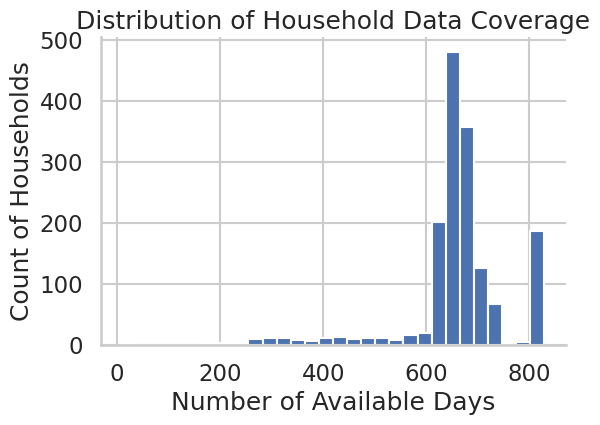

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(coverage["n_days"], bins=30)
plt.title("Distribution of Household Data Coverage")
plt.xlabel("Number of Available Days")
plt.ylabel("Count of Households")
plt.show()

## **8. Load Weather Data**

In [ ]:
def load_ecad(path: str, value_col: str, q_col: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=20)
    df.columns = ["SOUID", "DATE", value_col, q_col]
    df["date"] = pd.to_datetime(df["DATE"], format="%Y%m%d", errors="coerce")
    return df[["date", value_col]]

tg = load_ecad(tg_path, "TG", "Q_TG")
tx = load_ecad(tx_path, "TX", "Q_TX")
tn = load_ecad(tn_path, "TN", "Q_TN")

tg["temp_mean"] = tg["TG"] / 10
tx["temp_max"] = tx["TX"] / 10
tn["temp_min"] = tn["TN"] / 10

weather = (
    tg[["date", "temp_mean"]]
    .merge(tx[["date", "temp_max"]], on="date", how="inner")
    .merge(tn[["date", "temp_min"]], on="date", how="inner")
)

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (17166, 4)


,date,temp_mean,temp_max,temp_min
0,1979-01-02,-2.600,1.600,-7.500
1,1979-01-03,-2.800,1.300,-7.200
2,1979-01-04,-2.600,-0.300,-6.500
3,1979-01-05,-0.800,5.600,-1.400
4,1979-01-06,-0.500,8.300,-6.600


## **9. Load Carbon Intensity Data**

In [ ]:
carbon_raw = pd.read_csv(carbon_path)
carbon_raw["DATETIME"] = pd.to_datetime(carbon_raw["DATETIME"], errors="coerce")
carbon_raw["date"] = carbon_raw["DATETIME"].dt.normalize()

carbon_daily = (
    carbon_raw.groupby("date", as_index=False)["CARBON_INTENSITY"]
    .mean()
    .rename(columns={"CARBON_INTENSITY": "carbon_intensity"})
)

print("Carbon daily shape:", carbon_daily.shape)
carbon_daily.head()

Carbon daily shape: (6263, 2)


,date,carbon_intensity
0,2009-01-01,541.688
1,2009-01-02,571.938
2,2009-01-03,566.750
3,2009-01-04,565.938
4,2009-01-05,586.042


## **10. Merge Energy, Weather, and Carbon Data**

In [ ]:
start_date = energy_daily["date"].min()
end_date = energy_daily["date"].max()

weather_f = weather[(weather["date"] >= start_date) & (weather["date"] <= end_date)].copy()
carbon_f = carbon_daily[(carbon_daily["date"] >= start_date) & (carbon_daily["date"] <= end_date)].copy()

merged = energy_daily.merge(weather_f, on="date", how="left")
merged2 = merged.merge(carbon_f, on="date", how="left")

print("Merged shape:", merged2.shape)
print("Missing values:")
print(merged2[["temp_mean", "temp_max", "temp_min", "carbon_intensity"]].isna().sum())

merged2.head()

Merged shape: (1045743, 8)
Missing values:
temp_mean           0
temp_max            0
temp_min            0
carbon_intensity    0
dtype: int64


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity
0,MAC000002,2012-10-12,7.098,2.092,12.300,13.500,9.700,527.625
1,MAC000002,2012-10-13,11.087,2.492,9.600,12.900,5.600,556.479
2,MAC000002,2012-10-14,13.223,2.655,7.400,14.200,1.900,547.667
3,MAC000002,2012-10-15,10.257,2.421,8.600,15.900,2.900,549.333
4,MAC000002,2012-10-16,9.769,2.377,12.100,17.500,8.300,540.667


## **11. Exploratory Data Analysis**

### **11.1 Distribution of Log Consumption**

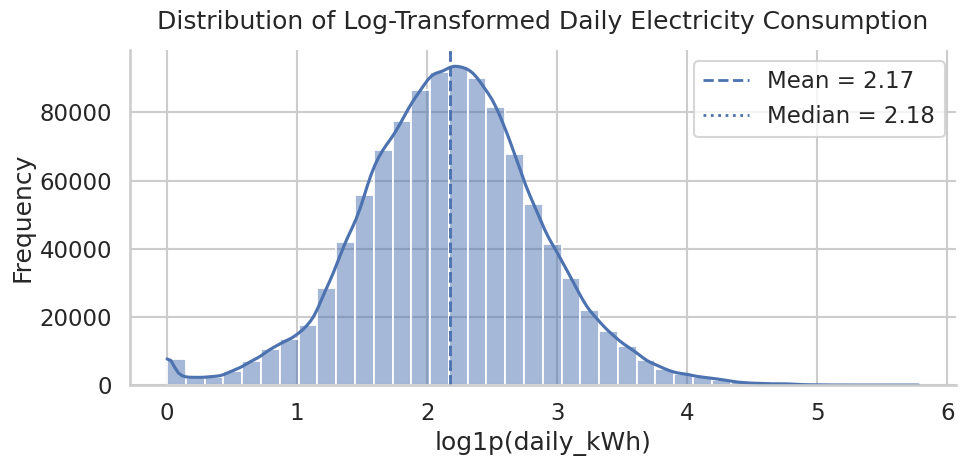

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=merged2,
    x="daily_kWh_log",
    bins=40,
    kde=True,
    ax=ax
)

mean_val = merged2["daily_kWh_log"].mean()
median_val = merged2["daily_kWh_log"].median()

ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
ax.axvline(median_val, linestyle=":", linewidth=2, label=f"Median = {median_val:.2f}")

ax.set_title("Distribution of Log-Transformed Daily Electricity Consumption", pad=15)
ax.set_xlabel("log1p(daily_kWh)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## **11.2 Correlation Matrix**

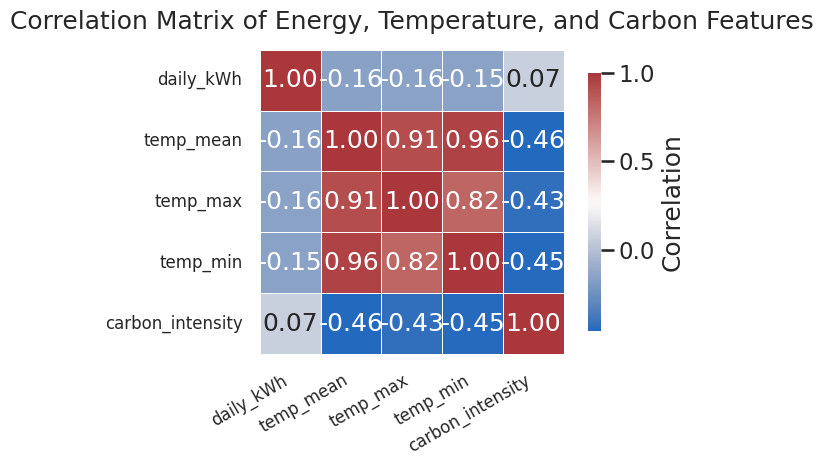

In [ ]:
corr = merged2[["daily_kWh", "temp_mean", "temp_max", "temp_min", "carbon_intensity"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="vlag",
    fmt=".2f",
    linewidths=0.7,
    square=True,
    cbar_kws={"shrink": 0.85, "label": "Correlation"}
)
plt.title("Correlation Matrix of Energy, Temperature, and Carbon Features", pad=15)
plt.xticks(fontsize=12, rotation=30, ha="right")
plt.yticks(fontsize=12,rotation=0)
plt.tight_layout()
plt.show()

### **11.3 Monthly Seasonality**

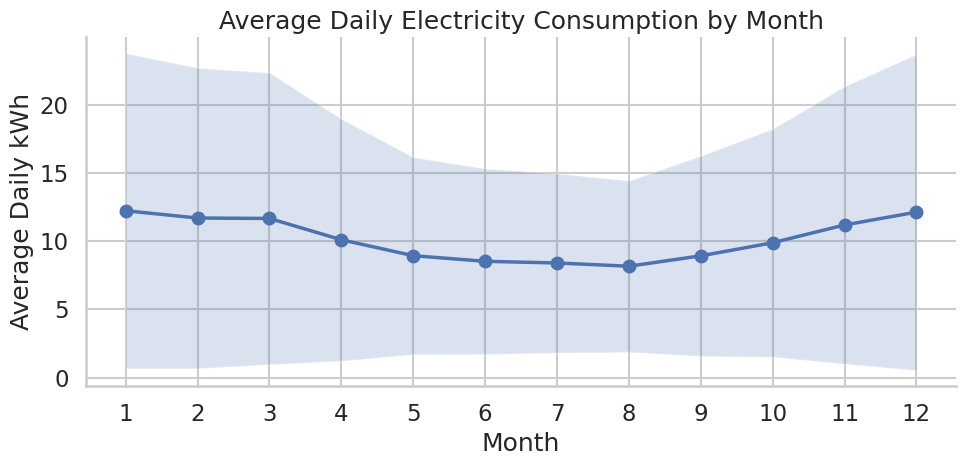

In [ ]:
monthly_stats = merged2.groupby(merged2["date"].dt.month)["daily_kWh"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_stats["date"], monthly_stats["mean"], marker="o", linewidth=2.5)
plt.fill_between(
    monthly_stats["date"],
    monthly_stats["mean"] - monthly_stats["std"],
    monthly_stats["mean"] + monthly_stats["std"],
    alpha=0.2
)
plt.title("Average Daily Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily kWh")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### **11.4 Outliers**

Outlier rows: 61407
Outlier percentage: 5.87 %


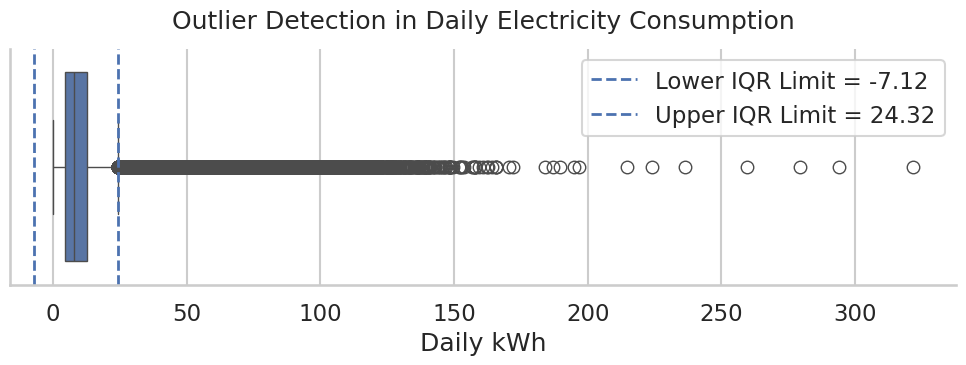

In [ ]:
Q1 = merged2["daily_kWh"].quantile(0.25)
Q3 = merged2["daily_kWh"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged2[(merged2["daily_kWh"] < lower) | (merged2["daily_kWh"] > upper)]

print("Outlier rows:", len(outliers))
print("Outlier percentage:", round(100 * len(outliers) / len(merged2), 2), "%")

fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(x=merged2["daily_kWh"], ax=ax)
ax.axvline(lower, linestyle="--", linewidth=2, label=f"Lower IQR Limit = {lower:.2f}")
ax.axvline(upper, linestyle="--", linewidth=2, label=f"Upper IQR Limit = {upper:.2f}")

ax.set_title("Outlier Detection in Daily Electricity Consumption", pad=15)
ax.set_xlabel("Daily kWh")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

### **11.5 Temperature vs Energy**

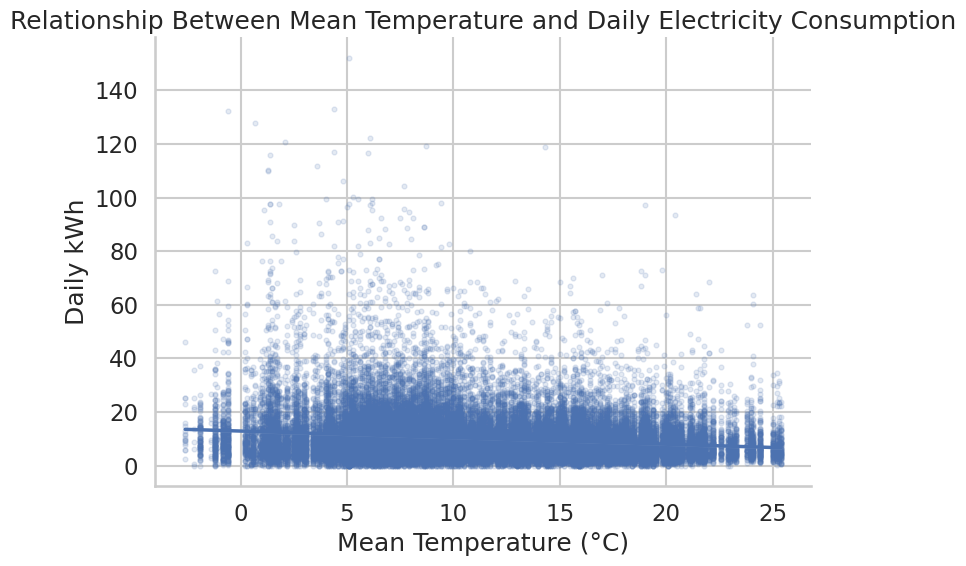

In [ ]:
sample_df = merged2.sample(min(50000, len(merged2)), random_state=42)

plt.figure(figsize=(8, 6))
sns.regplot(
    data=sample_df,
    x="temp_mean",
    y="daily_kWh",
    scatter_kws={"alpha": 0.15, "s": 12},
    line_kws={"linewidth": 2.5}
)
plt.title("Relationship Between Mean Temperature and Daily Electricity Consumption")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Daily kWh")
plt.tight_layout()
plt.show()

### **11.6 Seasonal Heatmap of Electricity Consumption by Year and Month**

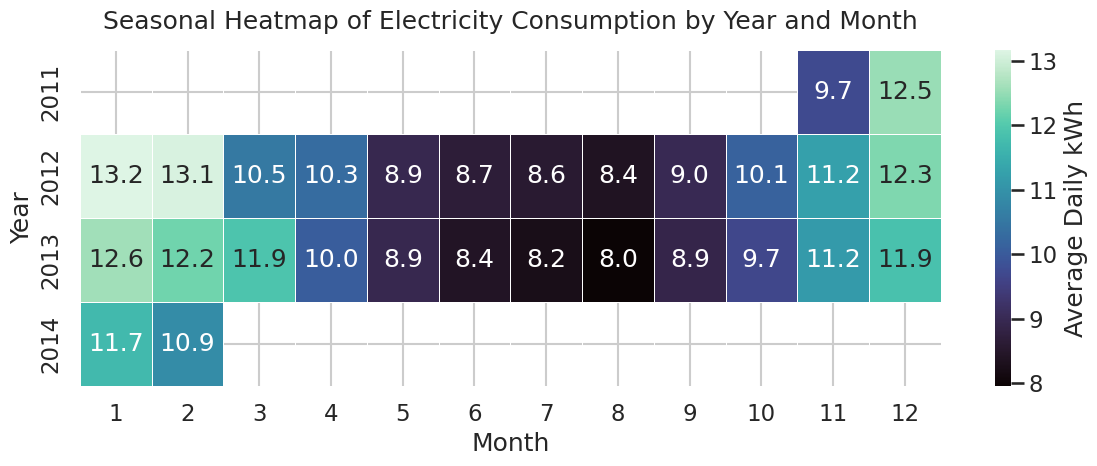

In [ ]:
season_df = merged2.copy()
season_df["year"] = season_df["date"].dt.year
season_df["month"] = season_df["date"].dt.month

season_pivot = season_df.groupby(["year", "month"])["daily_kWh"].mean().unstack()

plt.figure(figsize=(12, 5))
sns.heatmap(
    season_pivot,
    cmap="mako",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Average Daily kWh"}
)
plt.title("Seasonal Heatmap of Electricity Consumption by Year and Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

### **11.7 Missingness Check**

In [ ]:
missing_summary = merged2.isna().mean().sort_values(ascending=False) * 100
missing_summary

,0
LCLid,0.000
date,0.000
daily_kWh,0.000
daily_kWh_log,0.000
temp_mean,0.000
temp_max,0.000
temp_min,0.000
carbon_intensity,0.000


## **12. Feature Engineering**

In [ ]:
df = merged2.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["LCLid", "date"]).reset_index(drop=True)

# Calendar features
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_month"] = df["date"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Cyclical encoding
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Weather/context features
df["HDD_18"] = np.maximum(0, 18 - df["temp_mean"])
df["temp_range"] = df["temp_max"] - df["temp_min"]
df["is_winter"] = df["month"].isin([12, 1, 2]).astype(int)
df["is_summer"] = df["month"].isin([6, 7, 8]).astype(int)

# Lag features
lag_days = [1, 2, 3, 7, 14, 30]
for L in lag_days:
    df[f"lag_{L}"] = df.groupby("LCLid")["daily_kWh"].shift(L)

# Rolling features without leakage
roll_windows = [7, 14, 30]
g = df.groupby("LCLid")["daily_kWh"]
for w in roll_windows:
    shifted = g.shift(1)
    df[f"roll_mean_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).mean()
    df[f"roll_std_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).std()
    df[f"roll_min_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).min()
    df[f"roll_max_{w}"] = shifted.rolling(w, min_periods=max(3, w//3)).max()

needed = [f"lag_{L}" for L in lag_days] + [f"roll_mean_{w}" for w in roll_windows]
df_model = df.dropna(subset=needed + ["temp_mean", "carbon_intensity"]).copy()

print("Model-ready shape:", df_model.shape)
df_model.head()

Model-ready shape: (998187, 39)


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity,day_of_week,month,year,day_of_month,is_weekend,dow_sin,dow_cos,month_sin,month_cos,HDD_18,temp_range,is_winter,is_summer,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,roll_mean_7,roll_std_7,roll_min_7,roll_max_7,roll_mean_14,roll_std_14,roll_min_14,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30
30,MAC000002,2012-11-11,10.699,2.460,6.000,12.700,1.300,541.438,6,11,2012,11,1,-0.782,0.623,-0.500,0.866,12.000,11.400,0,0,13.245,16.722,0.186,14.507,19.629,7.098,12.079,5.487,0.186,16.722,13.561,4.431,0.186,19.629,13.447,4.395,0.186,24.490
31,MAC000002,2012-11-12,12.321,2.589,8.000,15.500,3.200,535.438,0,11,2012,12,0,0.000,1.000,-0.500,0.866,10.000,12.300,0,0,10.699,13.245,16.722,15.095,12.779,11.087,11.535,5.394,0.186,16.722,12.923,4.122,0.186,17.822,13.567,4.263,0.186,24.490
32,MAC000002,2012-11-13,10.264,2.422,11.400,14.200,7.300,525.167,1,11,2012,13,0,0.782,0.623,-0.500,0.866,6.600,6.900,0,0,12.321,10.699,13.245,11.663,13.961,13.223,11.139,5.187,0.186,16.722,12.891,4.125,0.186,17.822,13.608,4.244,0.186,24.490
33,MAC000002,2012-11-14,10.820,2.470,12.000,10.100,9.700,563.188,2,11,2012,14,0,0.975,-0.223,-0.500,0.866,6.000,0.400,0,0,10.264,12.321,10.699,13.137,17.822,10.257,10.939,5.190,0.186,16.722,12.626,4.169,0.186,17.822,13.510,4.288,0.186,24.490
34,MAC000002,2012-11-15,9.808,2.380,7.100,12.600,4.000,581.688,3,11,2012,15,0,0.434,-0.901,-0.500,0.866,10.900,8.600,0,0,10.820,10.264,12.321,0.186,12.209,9.769,10.608,5.100,0.186,16.722,12.126,3.910,0.186,16.722,13.528,4.274,0.186,24.490


## **13. Train, Validation, and Test Split**

In [ ]:
TEST_DAYS = 60
VAL_DAYS = 30

merged2 = merged2.sort_values(["LCLid", "date"]).copy()
merged2["date"] = pd.to_datetime(merged2["date"])

def temporal_split(df_home, val_days=30, test_days=60, date_col="date"):
    df_home = df_home.sort_values(date_col).copy()
    max_date = df_home[date_col].max()

    test_start = max_date - pd.Timedelta(days=test_days - 1)
    val_start = test_start - pd.Timedelta(days=val_days)

    train_df = df_home[df_home[date_col] < val_start].copy()
    val_df = df_home[(df_home[date_col] >= val_start) & (df_home[date_col] < test_start)].copy()
    test_df = df_home[df_home[date_col] >= test_start].copy()

    return train_df, val_df, test_df, val_start, test_start

# optional global reference dates
max_date = merged2["date"].max()
test_start = max_date - pd.Timedelta(days=TEST_DAYS - 1)
val_start = test_start - pd.Timedelta(days=VAL_DAYS)

print("Validation starts:", val_start)
print("Test starts:", test_start)
print("Max date:", max_date)

Validation starts: 2013-12-01 00:00:00
Test starts: 2013-12-31 00:00:00
Max date: 2014-02-28 00:00:00


## **14. Select Eligible Households**

In [ ]:
coverage2 = merged2.groupby("LCLid").agg(
    n_days=("date", "count"),
    start=("date", "min"),
    end=("date", "max")
).reset_index()

eligible_households = coverage2.loc[coverage2["n_days"] >= 150, "LCLid"].tolist()

print("Eligible households:", len(eligible_households))
print("Example households:", eligible_households[:10])

Eligible households: 1584
Example households: ['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012']


In [ ]:
N_HOUSEHOLDS = 50
selected_households = eligible_households[:N_HOUSEHOLDS]

print("Selected households:", selected_households[:10])

Selected households: ['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012']


In [ ]:
# Household Selection Tools

def get_household_data(merged_df, df_model, house_id):
    raw_home = merged_df[merged_df["LCLid"] == house_id].copy().sort_values("date")
    model_home = df_model[df_model["LCLid"] == house_id].copy().sort_values("date")

    if raw_home.empty:
        raise ValueError(f"No raw data found for household {house_id}")

    return raw_home, model_home

# Select any household manually
SELECTED_HOUSE = eligible_households[0]   # change this anytime
print("Selected household for deep analysis:", SELECTED_HOUSE)

Selected household for deep analysis: MAC000002


## **15. Drift Detection Functions**

### **15.1 CUSUM**

In [ ]:
def cusum_drift(residuals):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    sigma = np.std(residuals)
    if sigma == 0 or np.isnan(sigma):
        n = len(residuals)
        return np.zeros(n), np.zeros(n), np.zeros(n, dtype=bool), 0.0, 0.0

    k = 0.5 * sigma
    h = 5.0 * sigma

    cusum_pos = [0.0]
    cusum_neg = [0.0]

    for i in range(1, len(residuals)):
        cp = max(0.0, cusum_pos[-1] + residuals[i] - k)
        cn = min(0.0, cusum_neg[-1] + residuals[i] + k)
        cusum_pos.append(cp)
        cusum_neg.append(cn)

    cusum_pos = np.array(cusum_pos)
    cusum_neg = np.array(cusum_neg)
    alerts = (cusum_pos > h) | (cusum_neg < -h)

    return cusum_pos, cusum_neg, alerts, k, h

### **15.2 EWMA**

In [ ]:
def ewma_drift(residuals, alpha=0.3, threshold=2.0):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    if len(residuals) == 0:
        return np.array([]), np.array([], dtype=bool), np.nan, np.nan

    ewma = []
    s = residuals[0]

    for r in residuals:
        s = alpha * r + (1 - alpha) * s
        ewma.append(s)

    ewma = np.array(ewma)
    mean_ewma = np.mean(ewma)
    std_ewma = np.std(ewma)

    if std_ewma == 0 or np.isnan(std_ewma):
        alerts = np.zeros(len(ewma), dtype=bool)
        upper = mean_ewma
        lower = mean_ewma
    else:
        upper = mean_ewma + threshold * std_ewma
        lower = mean_ewma - threshold * std_ewma
        alerts = (ewma > upper) | (ewma < lower)

    return ewma, alerts, upper, lower

## **16. STL Baseline**

In [ ]:
def stl_baseline(df_home, period=7, min_days=30):
    x = df_home[["date", "daily_kWh"]].dropna().sort_values("date").copy()
    x = x.set_index("date").asfreq("D")
    x["daily_kWh"] = x["daily_kWh"].interpolate(limit=7)

    if x["daily_kWh"].dropna().shape[0] < min_days:
        return None

    stl = STL(x["daily_kWh"], period=period, robust=True)
    res = stl.fit()

    x["trend"] = res.trend
    x["seasonal"] = res.seasonal
    x["expected_kWh"] = res.trend + res.seasonal
    x["residual"] = x["daily_kWh"] - x["expected_kWh"]

    return x.reset_index()

## **17. Early Detection Evaluation**

In [ ]:
def evaluate_early_detection(home_test, alert_col="cusum_alert", residual_col="residual_test", consecutive_days=3):
    temp = home_test.copy()

    if temp.empty:
        return {
            "event_date": pd.NaT,
            "first_alert": pd.NaT,
            "lead_time_days": np.nan,
            "false_alarm_rate": np.nan,
            "stability_score": np.nan,
            "event_threshold": np.nan,
        }

    threshold = temp[residual_col].mean() + temp[residual_col].std()
    temp["event_flag"] = (temp[residual_col] > threshold).astype(int)
    temp["event_run"] = temp["event_flag"].rolling(consecutive_days).sum()

    event_date = temp.loc[temp["event_run"] >= consecutive_days, "date"].min()
    first_alert = temp.loc[temp[alert_col], "date"].min()

    lead_time = (event_date - first_alert).days if pd.notna(event_date) and pd.notna(first_alert) else np.nan

    false_alarms = (
        temp[(temp[alert_col] == True) & (temp["date"] < event_date)]
        if pd.notna(event_date)
        else pd.DataFrame()
    )
    false_alarm_rate = len(false_alarms) / len(temp) if len(temp) > 0 else np.nan
    stability = temp[alert_col].rolling(consecutive_days).sum().max()

    return {
        "event_date": event_date,
        "first_alert": first_alert,
        "lead_time_days": lead_time,
        "false_alarm_rate": false_alarm_rate,
        "stability_score": stability,
        "event_threshold": threshold,
    }

In [ ]:
def run_stl_for_household(df_home, test_start, period=7):
    df_home = df_home.sort_values("date").copy()

    train_home = df_home[df_home["date"] < test_start].copy()
    test_home = df_home[df_home["date"] >= test_start].copy()

    if len(train_home) < 60 or len(test_home) == 0:
        return None, None

    train_stl = stl_baseline(train_home, period=period)
    if train_stl is None:
        return None, None

    expected_vals = []
    residuals = []

    values = df_home["daily_kWh"].values
    dates = df_home["date"].values

    for i in range(len(df_home)):
        # pseudo real-time logic: use only past data
        if dates[i] < np.datetime64(test_start):
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        past_df = df_home.iloc[:i]
        if len(past_df) < 30:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        stl_df = stl_baseline(past_df, period=period)
        if stl_df is None:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        expected_today = stl_df["expected_kWh"].iloc[-7:].mean()
        expected_vals.append(expected_today)
        residuals.append(values[i] - expected_today)

    df_home["expected_test"] = expected_vals
    df_home["residual_test"] = residuals

    home_test = df_home[df_home["date"] >= test_start].copy()
    r = home_test["residual_test"].fillna(0).values

    cusum_pos, cusum_neg, cusum_alert, k, h = cusum_drift(r)
    ewma_vals, ewma_alert, ewma_upper, ewma_lower = ewma_drift(r)

    home_test["cusum_pos"] = cusum_pos
    home_test["cusum_neg"] = cusum_neg
    home_test["cusum_alert"] = cusum_alert
    home_test["cusum_k"] = k
    home_test["cusum_h"] = h

    home_test["ewma"] = ewma_vals
    home_test["ewma_alert"] = ewma_alert
    home_test["ewma_upper"] = ewma_upper
    home_test["ewma_lower"] = ewma_lower

    summary = pd.DataFrame({
        "LCLid": [df_home["LCLid"].iloc[0]],
        "cusum_first_alert": [home_test.loc[home_test["cusum_alert"], "date"].min()],
        "cusum_num_alerts": [int(home_test["cusum_alert"].sum())],
        "cusum_max_drift": [float(np.max(np.abs(home_test["cusum_neg"]))) if len(home_test) else np.nan],
        "ewma_first_alert": [home_test.loc[home_test["ewma_alert"], "date"].min()],
        "ewma_num_alerts": [int(home_test["ewma_alert"].sum())],
        "ewma_max_drift": [float(np.max(np.abs(home_test["ewma"]))) if len(home_test) else np.nan]
    })

    return summary, home_test

## **19. Forecast Metrics Function**

In [ ]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    r2 = r2_score(y_true, y_pred)

    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "smape": smape,
        "r2": r2
    }

In [ ]:
def calculate_naive_forecast_metrics(train, test, seasonal_lag):
    pred = seasonal_naive_forecast(train["daily_kWh"], test.index, seasonal_lag=seasonal_lag)
    actual = test["daily_kWh"].values
    error = actual - pred
    metrics = regression_metrics(actual, pred)

    pred_df = pd.DataFrame({
        "date": test.index,
        "actual": actual,
        "predicted": pred,
        "error": error
    }).reset_index(drop=True)

    summary = pd.DataFrame({
        "naive_mae": [metrics["mae"]],
        "naive_rmse": [metrics["rmse"]],
        "naive_mape": [metrics["mape"]],
        "naive_smape": [metrics["smape"]],
        "naive_r2": [metrics["r2"]],
    })

    return summary, pred_df

## **20. TCN Model for One Household**

In [ ]:
def run_tcn_for_household(df_home, house_id, val_start, test_start, lookback=30, epochs=20):
    df_home = df_home.sort_values("date")[["date", "daily_kWh"]].dropna().copy()

    if len(df_home) < lookback + 100:
        return None, None, None, None

    scaler = MinMaxScaler()
    df_home["scaled"] = scaler.fit_transform(df_home[["daily_kWh"]])

    X, y, dates = [], [], []
    series = df_home["scaled"].values
    date_vals = df_home["date"].values

    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
        dates.append(date_vals[i])

    X = np.array(X)
    y = np.array(y)
    dates = pd.to_datetime(np.array(dates))

    train_mask = dates < val_start
    val_mask = (dates >= val_start) & (dates < test_start)
    test_mask = dates >= test_start

    if train_mask.sum() < 50 or test_mask.sum() == 0:
        return None, None, None, None

    X_train = X[train_mask][..., np.newaxis]
    y_train = y[train_mask]
    X_test = X[test_mask][..., np.newaxis]
    y_test = y[test_mask]
    test_dates = dates[test_mask]

    model = Sequential([
        TCN(32, dropout_rate=0.1),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    callbacks = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

    history = None
    if val_mask.sum() > 0:
        X_val = X[val_mask][..., np.newaxis]
        y_val = y[val_mask]
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=16,
            verbose=0,
            callbacks=callbacks
        )
    else:
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=16,
            verbose=0
        )

    pred_scaled = model.predict(X_test, verbose=0).flatten()
    pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    errors = y_actual - pred
    cusum_pos, cusum_neg, alerts, k, h = cusum_drift(errors)

    metrics = regression_metrics(y_actual, pred)

    summary = pd.DataFrame({
        "LCLid": [house_id],
        "tcn_first_alert": [test_dates[np.where(alerts)[0][0]] if alerts.any() else pd.NaT],
        "tcn_num_alerts": [int(alerts.sum())],
        "tcn_max_drift": [float(np.max(cusum_pos)) if len(cusum_pos) else np.nan],
        "tcn_mae": [metrics["mae"]],
        "tcn_rmse": [metrics["rmse"]],
        "tcn_mape": [metrics["mape"]],
        "tcn_smape": [metrics["smape"]],
        "tcn_r2": [metrics["r2"]]
    })

    pred_df = pd.DataFrame({
        "LCLid": house_id,
        "date": test_dates,
        "actual": y_actual,
        "predicted": pred,
        "error": errors,
        "tcn_alert": alerts
    })

    return summary, pred_df, model, history

## **21. XGBoost Model for One Household**

In [ ]:
def run_xgb_for_household(df_model, house_id, val_start, test_start):
    df_home = df_model[df_model["LCLid"] == house_id].copy()

    train_df = df_home[df_home["date"] < val_start].copy()
    val_df_ = df_home[(df_home["date"] >= val_start) & (df_home["date"] < test_start)].copy()
    test_df = df_home[df_home["date"] >= test_start].copy()

    if len(train_df) < 100 or len(test_df) == 0:
        return None, None, None

    feature_cols = [c for c in df_home.columns if c not in ["LCLid", "date", "daily_kWh", "daily_kWh_log"]]
    if len(feature_cols) == 0:
        return None, None, None

    X_train = train_df[feature_cols]
    y_train = train_df["daily_kWh"]
    X_val = val_df_[feature_cols] if len(val_df_) > 0 else None
    y_val = val_df_["daily_kWh"] if len(val_df_) > 0 else None
    X_test = test_df[feature_cols]
    y_test = test_df["daily_kWh"]

    param_grid = [
        {"n_estimators": 100, "max_depth": 4, "learning_rate": 0.05},
        {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05},
        {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.03},
    ]

    best_model = None
    best_score = np.inf

    for params in param_grid:
        model = XGBRegressor(
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            **params
        )
        model.fit(X_train, y_train)

        if X_val is not None and len(X_val) > 0:
            val_pred = model.predict(X_val)
            val_mae = mean_absolute_error(y_val, val_pred)
            if val_mae < best_score:
                best_score = val_mae
                best_model = model
        else:
            best_model = model

    model = best_model
    pred = model.predict(X_test)
    errors = y_test.values - pred

    cusum_pos, cusum_neg, alerts, k, h = cusum_drift(errors)
    metrics = regression_metrics(y_test.values, pred)

    summary = pd.DataFrame({
        "LCLid": [house_id],
        "xgb_first_alert": [test_df["date"].iloc[np.where(alerts)[0][0]] if alerts.any() else pd.NaT],
        "xgb_num_alerts": [int(alerts.sum())],
        "xgb_max_drift": [float(np.max(cusum_pos)) if len(cusum_pos) else np.nan],
        "xgb_mae": [metrics["mae"]],
        "xgb_rmse": [metrics["rmse"]],
        "xgb_mape": [metrics["mape"]],
        "xgb_smape": [metrics["smape"]],
        "xgb_r2": [metrics["r2"]]
    })

    pred_df = pd.DataFrame({
        "LCLid": house_id,
        "date": test_df["date"].values,
        "actual": y_test.values,
        "predicted": pred,
        "error": errors,
        "xgb_alert": alerts
    })

    return summary, pred_df, model

In [ ]:
def seasonal_naive_forecast(series, index, seasonal_lag):
    forecast = pd.Series(index=index)
    for i in range(len(index)):
        current_date = index[i]
        past_date = current_date - pd.Timedelta(days=seasonal_lag)

        if past_date in series.index:
            forecast.loc[current_date] = series.loc[past_date]
        else:
            forecast.loc[current_date] = np.nan

    return forecast.fillna(method='bfill').fillna(method='ffill')

def run_seasonal_naive_for_household(df_home, test_start, seasonal_lag=7):
    df_home = df_home.set_index('date').sort_index()
    train_df = df_home[df_home.index < test_start].copy()
    test_df = df_home[df_home.index >= test_start].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        return None, None

    summary, pred_df = calculate_naive_forecast_metrics(train_df, test_df, seasonal_lag)
    return summary, pred_df

def compute_excess_carbon(home_test, residual_col="residual_test"):
    temp = home_test.copy()
    temp["positive_residual"] = temp[residual_col].clip(lower=0)
    temp["excess_carbon_g"] = temp["positive_residual"] * temp["carbon_intensity"]
    return temp

def run_full_household_analysis(house_id, merged2, df_model, val_days=30, test_days=60, tcn_epochs=20):
    raw_home, model_home = get_household_data(merged2, df_model, house_id)

    train_raw, val_raw, test_raw, val_start, test_start = temporal_split(
        raw_home, val_days=val_days, test_days=test_days
    )

    stl_summary, stl_test = run_stl_for_household(raw_home, test_start=test_start, period=7)

    tcn_summary, tcn_pred_df, tcn_model, tcn_history = run_tcn_for_household(
        df_home=raw_home,
        house_id=house_id,
        val_start=val_start,
        test_start=test_start,
        lookback=30,
        epochs=tcn_epochs
    )

    xgb_summary, xgb_pred_df, xgb_model = run_xgb_for_household(
        df_model=df_model,
        house_id=house_id,
        val_start=val_start,
        test_start=test_start
    )

    naive_summary, naive_pred_df = run_seasonal_naive_for_household(
        raw_home,
        test_start=test_start,
        seasonal_lag=7
    )

    early_cusum, early_ewma = None, None
    if stl_test is not None:
        early_cusum = evaluate_early_detection(
            stl_test, alert_col="cusum_alert", residual_col="residual_test"
        )
        early_ewma = evaluate_early_detection(
            stl_test, alert_col="ewma_alert", residual_col="residual_test"
        )

    carbon_result = None
    if stl_test is not None:
        carbon_df = compute_excess_carbon(stl_test, residual_col="residual_test")
        carbon_result = {
            "house_id": house_id,
            "excess_energy_kwh": carbon_df["positive_residual"].sum(),
            "excess_carbon_g": carbon_df["excess_carbon_g"].sum()
        }

    results = {
        "house_id": house_id,
        "val_start": val_start,
        "test_start": test_start,
        "raw_home": raw_home,
        "model_home": model_home,
        "stl_summary": stl_summary,
        "stl_test": stl_test,
        "tcn_summary": tcn_summary,
        "tcn_pred_df": tcn_pred_df,
        "tcn_model": tcn_model,
        "tcn_history": tcn_history,
        "xgb_summary": xgb_summary,
        "xgb_pred_df": xgb_pred_df,
        "xgb_model": xgb_model,
        "naive_summary": naive_summary,
        "naive_pred_df": naive_pred_df,
        "early_cusum": early_cusum,
        "early_ewma": early_ewma,
        "carbon_result": carbon_result
    }

    return results

In [ ]:
def build_household_summary_table(results):
    house_id = results["house_id"]
    row = {"LCLid": house_id}

    if results["naive_summary"] is not None:
        row.update(results["naive_summary"].iloc[0].to_dict())

    if results["tcn_summary"] is not None:
        row.update(results["tcn_summary"].iloc[0].to_dict())

    if results["xgb_summary"] is not None:
        row.update(results["xgb_summary"].iloc[0].to_dict())

    if results["stl_summary"] is not None:
        row.update(results["stl_summary"].iloc[0].to_dict())

    if results["carbon_result"] is not None:
        row["excess_energy_kwh"] = results["carbon_result"]["excess_energy_kwh"]
        row["excess_carbon_g"] = results["carbon_result"]["excess_carbon_g"]

    if results["early_cusum"] is not None:
        row["cusum_event_date"] = results["early_cusum"]["event_date"]
        row["cusum_first_alert_eval"] = results["early_cusum"]["first_alert"]
        row["cusum_lead_time_days"] = results["early_cusum"]["lead_time_days"]
        row["cusum_false_alarm_rate"] = results["early_cusum"]["false_alarm_rate"]

    if results["early_ewma"] is not None:
        row["ewma_event_date"] = results["early_ewma"]["event_date"]
        row["ewma_first_alert_eval"] = results["early_ewma"]["first_alert"]
        row["ewma_lead_time_days"] = results["early_ewma"]["lead_time_days"]
        row["ewma_false_alarm_rate"] = results["early_ewma"]["false_alarm_rate"]

    return pd.DataFrame([row])


def plot_household_forecasts(results):
    house_id = results["house_id"]
    raw_home = results["raw_home"]
    stl_test = results["stl_test"]
    tcn_pred_df = results["tcn_pred_df"]
    xgb_pred_df = results["xgb_pred_df"]
    naive_pred_df = results["naive_pred_df"]
    test_start = results["test_start"]

    plt.figure(figsize=(16, 6))
    plt.axvspan(test_start, raw_home["date"].max(), alpha=0.2, label="Test Period")

    plt.plot(raw_home["date"], raw_home["daily_kWh"], label="Actual", linewidth=2.8)

    if stl_test is not None and "expected_test" in stl_test.columns:
        plt.plot(stl_test["date"], stl_test["expected_test"], label="STL Expected", linewidth=2)

    if naive_pred_df is not None:
        plt.plot(naive_pred_df["date"], naive_pred_df["predicted"], label="Seasonal Naive", linewidth=2)

    if tcn_pred_df is not None:
        plt.plot(tcn_pred_df["date"], tcn_pred_df["predicted"], label="TCN Forecast", linewidth=2)

    if xgb_pred_df is not None:
        plt.plot(xgb_pred_df["date"], xgb_pred_df["predicted"], label="XGBoost Forecast", linewidth=2)

    plt.title(f"Forecast Comparison for Household {house_id}")
    plt.xlabel("Date")
    plt.ylabel("Daily Electricity Consumption (kWh)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_household_drift(results):
    stl_test = results["stl_test"]
    house_id = results["house_id"]
    test_start = results["test_start"]

    if stl_test is None:
        print("No STL drift results available.")
        return

    plt.figure(figsize=(16, 6))
    plt.axvspan(test_start, stl_test["date"].max(), alpha=0.2, label="Test Period")

    plt.plot(stl_test["date"], np.abs(stl_test["cusum_neg"]), label="CUSUM Magnitude", linewidth=2.2)
    plt.plot(stl_test["date"], np.abs(stl_test["ewma"]), label="EWMA Magnitude", linewidth=2.2)

    if "cusum_h" in stl_test.columns:
        plt.axhline(stl_test["cusum_h"].iloc[0], linestyle="--", label="CUSUM Threshold")

    if "ewma_upper" in stl_test.columns:
        plt.axhline(abs(stl_test["ewma_upper"].iloc[0]), linestyle=":", label="EWMA Threshold")

    alert_dates = stl_test.loc[stl_test["cusum_alert"] == True, "date"]
    for i, d in enumerate(alert_dates):
        plt.axvline(d, color="red", linestyle="--", alpha=0.3, label="CUSUM Alert" if i == 0 else "")

    plt.title(f"Drift Detection for Household {house_id}")
    plt.xlabel("Date")
    plt.ylabel("Drift Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_household_carbon(results):
    stl_test = results["stl_test"]
    house_id = results["house_id"]

    if stl_test is None:
        print("No STL results available for carbon analysis.")
        return

    temp = compute_excess_carbon(stl_test, residual_col="residual_test")

    plt.figure(figsize=(16, 5))
    plt.bar(temp["date"], temp["excess_carbon_g"])
    plt.title(f"Daily Excess Carbon Impact for Household {house_id}")
    plt.xlabel("Date")
    plt.ylabel("Excess Carbon (gCO2)")
    plt.tight_layout()
    plt.show()

## **22. Run All Models for Many Households**

In [ ]:
all_stl = []
all_eval_rows = []
all_tcn = []
all_xgb = []

stl_details = {}
tcn_details = {}
xgb_details = {}
tcn_histories = {}
xgb_models = {}

for house_id in selected_households:
    print(f"Running household: {house_id}")

    df_home = merged2[merged2["LCLid"] == house_id].copy()

    stl_summary, home_test = run_stl_for_household(df_home, test_start=test_start, period=7)
    if stl_summary is not None:
        all_stl.append(stl_summary)
        stl_details[house_id] = home_test

        eval_cusum = evaluate_early_detection(home_test, alert_col="cusum_alert", residual_col="residual_test")
        eval_ewma = evaluate_early_detection(home_test, alert_col="ewma_alert", residual_col="residual_test")

        all_eval_rows.append({"LCLid": house_id, "method": "CUSUM", **eval_cusum})
        all_eval_rows.append({"LCLid": house_id, "method": "EWMA", **eval_ewma})

    tcn_summary, tcn_pred_df, tcn_model, tcn_history = run_tcn_for_household(
        df_home=df_home,
        house_id=house_id,
        val_start=val_start,
        test_start=test_start,
        lookback=30,
        epochs=20
    )
    if tcn_summary is not None:
        all_tcn.append(tcn_summary)
        tcn_details[house_id] = tcn_pred_df
        tcn_histories[house_id] = tcn_history

    xgb_summary, xgb_pred_df, xgb_model = run_xgb_for_household(
        df_model=df_model,
        house_id=house_id,
        val_start=val_start,
        test_start=test_start
    )
    if xgb_summary is not None:
        all_xgb.append(xgb_summary)
        xgb_details[house_id] = xgb_pred_df
        xgb_models[house_id] = xgb_model

stl_drift_summary = pd.concat(all_stl, ignore_index=True) if all_stl else pd.DataFrame()
early_eval = pd.DataFrame(all_eval_rows)
tcn_summary_all = pd.concat(all_tcn, ignore_index=True) if all_tcn else pd.DataFrame()
xgb_summary_all = pd.concat(all_xgb, ignore_index=True) if all_xgb else pd.DataFrame()

print("STL summary shape:", stl_drift_summary.shape)
print("Early eval shape:", early_eval.shape)
print("TCN summary shape:", tcn_summary_all.shape)
print("XGB summary shape:", xgb_summary_all.shape)

Running household: MAC000002
Running household: MAC000003
Running household: MAC000004
Running household: MAC000006
Running household: MAC000007
Running household: MAC000008
Running household: MAC000009
Running household: MAC000010
Running household: MAC000011
Running household: MAC000012
Running household: MAC000013
Running household: MAC000016
Running household: MAC000018
Running household: MAC000019
Running household: MAC000020
Running household: MAC000021
Running household: MAC000022
Running household: MAC000023
Running household: MAC000024
Running household: MAC000025
Running household: MAC000026
Running household: MAC000027
Running household: MAC000028
Running household: MAC000029
Running household: MAC000030
Running household: MAC000032
Running household: MAC000033
Running household: MAC000034
Running household: MAC000035
Running household: MAC000036
Running household: MAC000037
Running household: MAC000038
Running household: MAC000039
Running household: MAC000040
Running househ

In [ ]:
# =========================
# Deep Analysis for Selected Household
# =========================

results = run_full_household_analysis(
    house_id=SELECTED_HOUSE,
    merged2=merged2,
    df_model=df_model,
    val_days=30,
    test_days=60,
    tcn_epochs=20
)

house_summary = build_household_summary_table(results)
display(house_summary)

,LCLid,naive_mae,naive_rmse,naive_mape,naive_smape,naive_r2,tcn_first_alert,tcn_num_alerts,tcn_max_drift,tcn_mae,tcn_rmse,tcn_mape,tcn_smape,tcn_r2,xgb_first_alert,xgb_num_alerts,xgb_max_drift,xgb_mae,xgb_rmse,xgb_mape,xgb_smape,xgb_r2,cusum_first_alert,cusum_num_alerts,cusum_max_drift,ewma_first_alert,ewma_num_alerts,ewma_max_drift,excess_energy_kwh,excess_carbon_g,cusum_event_date,cusum_first_alert_eval,cusum_lead_time_days,cusum_false_alarm_rate,ewma_event_date,ewma_first_alert_eval,ewma_lead_time_days,ewma_false_alarm_rate
0,MAC000002,3.155,4.415,25.647,22.712,-0.319,NaT,0,10.980,3.770,4.959,29.867,24.462,-0.663,2014-01-29,23,38.927,3.622,4.961,27.863,24.723,-0.665,2014-02-15,1,20.466,2014-01-27,3,4.599,86.192,"38,681.924",NaT,2014-02-15,NaN,0.000,NaT,2014-01-27,NaN,0.000


## **23. Final Comparison Table**

In [ ]:
comparison = stl_drift_summary.merge(tcn_summary_all, on="LCLid", how="outer")
comparison = comparison.merge(xgb_summary_all, on="LCLid", how="outer")

comparison.head()

,LCLid,cusum_first_alert,cusum_num_alerts,cusum_max_drift,ewma_first_alert,ewma_num_alerts,ewma_max_drift,tcn_first_alert,tcn_num_alerts,tcn_max_drift,tcn_mae,tcn_rmse,tcn_mape,tcn_smape,tcn_r2,xgb_first_alert,xgb_num_alerts,xgb_max_drift,xgb_mae,xgb_rmse,xgb_mape,xgb_smape,xgb_r2
0,MAC000002,2014-02-15,1,20.466,2014-01-27,3,4.599,NaT,0,27.078,4.784,6.048,36.150,35.534,-1.474,2014-01-29,23,38.927,3.622,4.961,27.863,24.723,-0.665
1,MAC000003,2014-01-16,2,53.522,2014-02-22,1,13.998,NaT,0,33.104,7.683,9.997,116.968,45.448,0.073,NaT,0,21.877,5.757,8.499,173.226,32.265,0.330
2,MAC000004,2014-02-28,1,1.480,2014-02-28,1,0.483,2014-02-28,1,0.211,0.135,0.239,21.926,9.042,-0.130,2014-02-28,1,0.073,0.121,0.247,22.552,8.060,-0.205
3,MAC000006,2014-02-28,1,2.873,2013-12-31,2,1.017,NaT,0,1.366,0.424,0.618,98.897,15.149,-0.319,2014-02-28,1,0.887,0.323,0.535,96.029,11.388,0.009
4,MAC000007,NaT,0,16.108,2014-01-04,4,5.621,NaT,0,23.096,3.855,5.414,190.954,33.240,-0.490,NaT,0,17.486,2.898,4.530,181.519,25.441,-0.044


## **24. Plot TCN Training and Validation Loss**

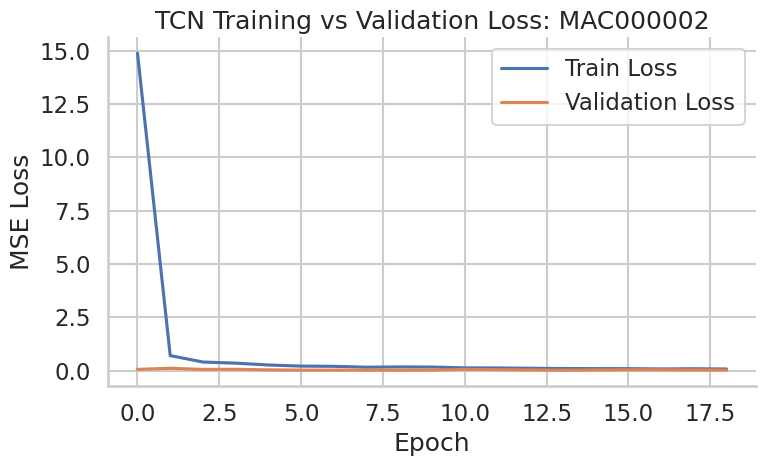

In [ ]:
example_house = SELECTED_HOUSE

if example_house in tcn_histories and tcn_histories[example_house] is not None:
    hist = tcn_histories[example_house].history
    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Train Loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"TCN Training vs Validation Loss: {example_house}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## **25. Top Households for Comparison**

In [ ]:
score_df = comparison.copy()

for col in [
    "cusum_num_alerts", "ewma_num_alerts", "tcn_num_alerts", "xgb_num_alerts",
    "cusum_max_drift", "ewma_max_drift", "tcn_max_drift", "xgb_max_drift",
    "tcn_mae", "xgb_mae"
]:
    if col in score_df.columns:
        score_df[col] = score_df[col].fillna(0)

score_df["active_methods"] = (
    (score_df["cusum_num_alerts"] > 0).astype(int) +
    (score_df["ewma_num_alerts"] > 0).astype(int) +
    (score_df["tcn_num_alerts"] > 0).astype(int) +
    (score_df["xgb_num_alerts"] > 0).astype(int)
)

score_df["total_alerts"] = (
    score_df["cusum_num_alerts"] +
    score_df["ewma_num_alerts"] +
    score_df["tcn_num_alerts"] +
    score_df["xgb_num_alerts"]
)

score_df["total_drift_score"] = (
    score_df["cusum_max_drift"] +
    score_df["ewma_max_drift"] +
    score_df["tcn_max_drift"] +
    score_df["xgb_max_drift"]
)

score_df["alert_variation"] = score_df[[
    "cusum_num_alerts", "ewma_num_alerts", "tcn_num_alerts", "xgb_num_alerts"
]].std(axis=1)

score_df["forecast_strength"] = (
    (score_df["tcn_mae"] > 0).astype(int) +
    (score_df["xgb_mae"] > 0).astype(int)
)

score_df["showcase_score"] = (
    3 * score_df["active_methods"] +
    0.10 * score_df["total_alerts"] +
    0.05 * score_df["total_drift_score"] +
    0.50 * score_df["alert_variation"] +
    2 * score_df["forecast_strength"]
)

best_households_df = score_df.sort_values("showcase_score", ascending=False).reset_index(drop=True)

best_house = best_households_df.loc[0, "LCLid"]
top_showcase_houses = best_households_df["LCLid"].head(6).tolist()

best_households_df[[
    "LCLid", "showcase_score", "active_methods", "total_alerts",
    "total_drift_score", "alert_variation"
]].head(10)

,LCLid,showcase_score,active_methods,total_alerts,total_drift_score,alert_variation
0,MAC000034,38.785,4,61,68.323,26.538
1,MAC000042,37.198,4,111,43.561,15.840
2,MAC000059,35.449,4,69,64.373,18.661
3,MAC000026,32.498,4,54,117.885,10.408
4,MAC000012,32.105,3,66,3.191,24.691
5,MAC000057,31.736,4,52,123.156,8.756
6,MAC000018,29.801,3,55,41.205,18.482
7,MAC000022,29.328,4,29,122.385,8.617
8,MAC000002,25.706,3,27,91.070,10.905
9,MAC000035,24.832,2,20,169.454,8.718


## **26. Main Showcase Plot**

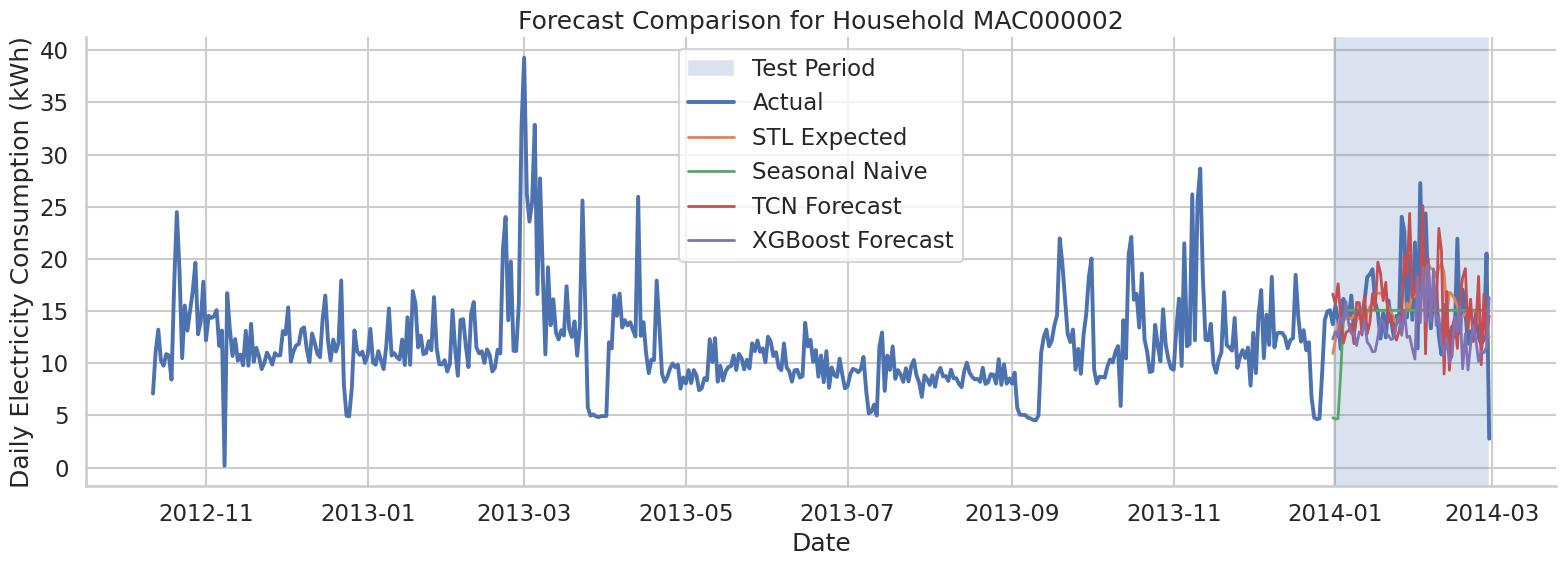

In [ ]:
plot_household_forecasts(results)

## **27. CUSUM vs EWMA Drift Plot**

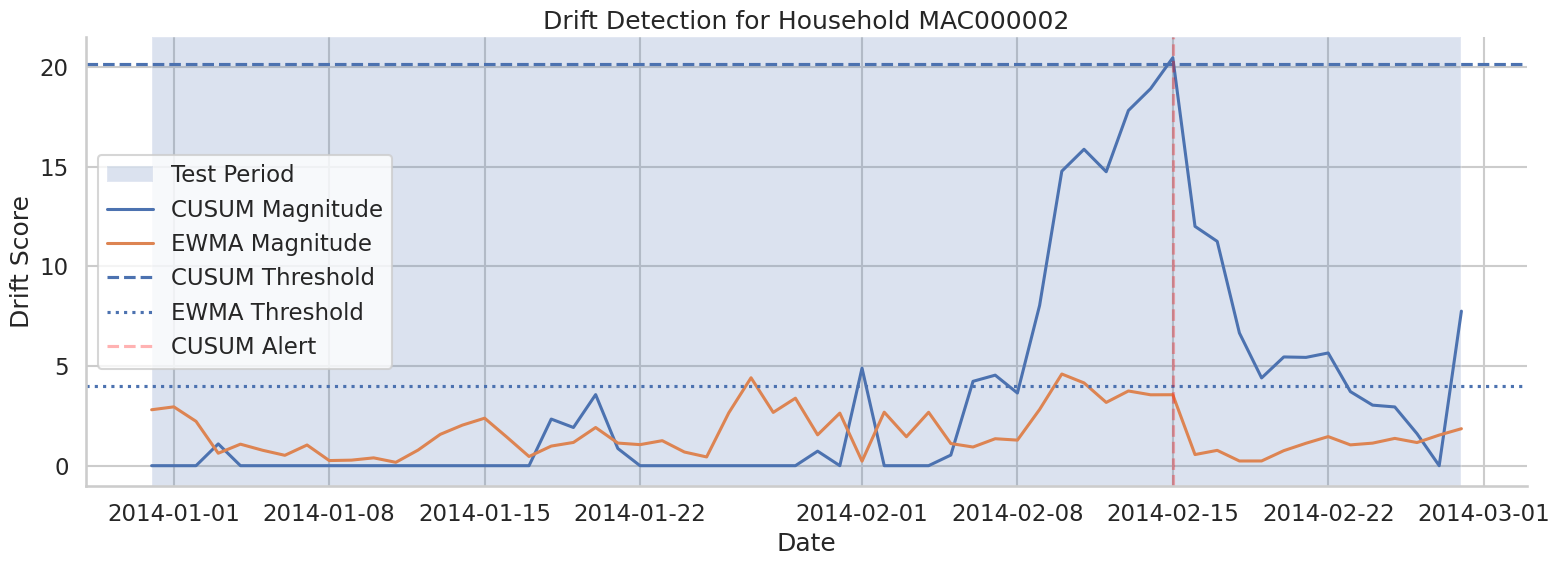

In [ ]:
plot_household_drift(results)


## **28. Alert Heatmap for Top Households**

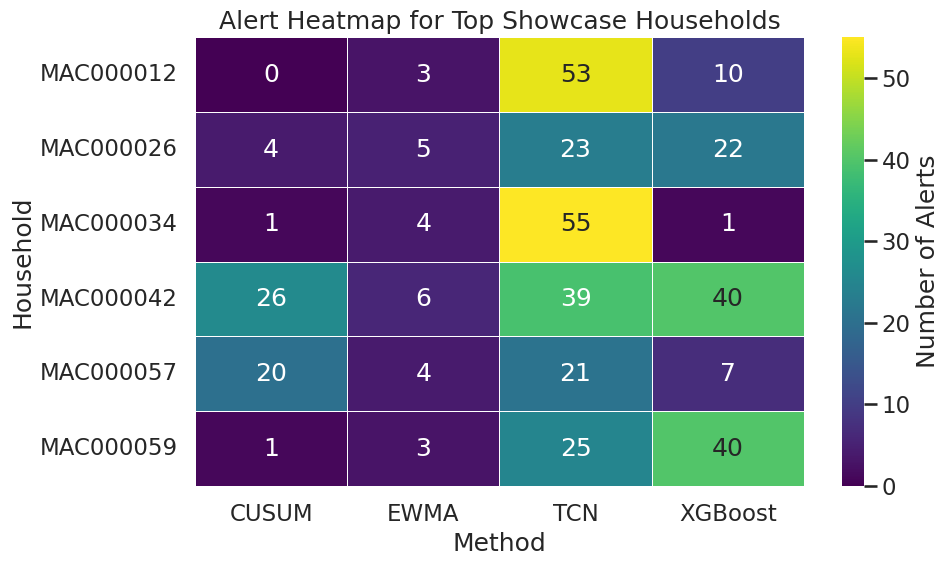

In [ ]:
compare_subset = comparison[comparison["LCLid"].isin(top_showcase_houses)].copy()

heatmap_df = compare_subset[[
    "LCLid",
    "cusum_num_alerts",
    "ewma_num_alerts",
    "tcn_num_alerts",
    "xgb_num_alerts"
]].copy()

heatmap_df.columns = ["LCLid", "CUSUM", "EWMA", "TCN", "XGBoost"]
heatmap_df = heatmap_df.set_index("LCLid")

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df.fillna(0),
    annot=True,
    fmt=".0f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Number of Alerts"}
)
plt.title("Alert Heatmap for Top Showcase Households")
plt.xlabel("Method")
plt.ylabel("Household")
plt.tight_layout()
plt.show()

## **29. Forecast Error Distribution**

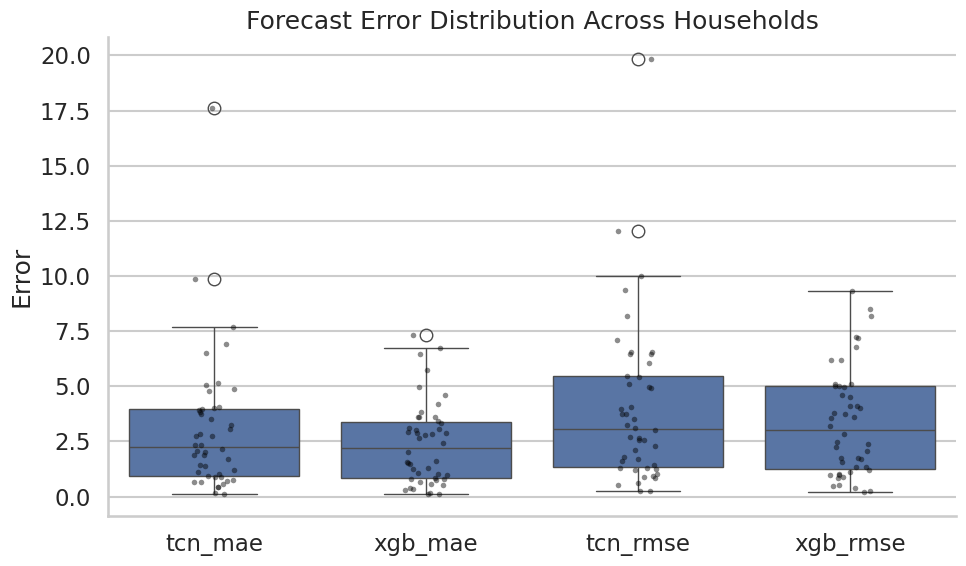

In [ ]:
error_long = comparison[["tcn_mae", "xgb_mae", "tcn_rmse", "xgb_rmse"]].copy()
error_long = error_long.melt(var_name="Metric", value_name="Value").dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(data=error_long, x="Metric", y="Value")
sns.stripplot(data=error_long, x="Metric", y="Value", color="black", alpha=0.45, size=4)
plt.title("Forecast Error Distribution Across Households")
plt.xlabel("")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

## **30. Explainable AI**

**30.1 SHAP for XGBoost**

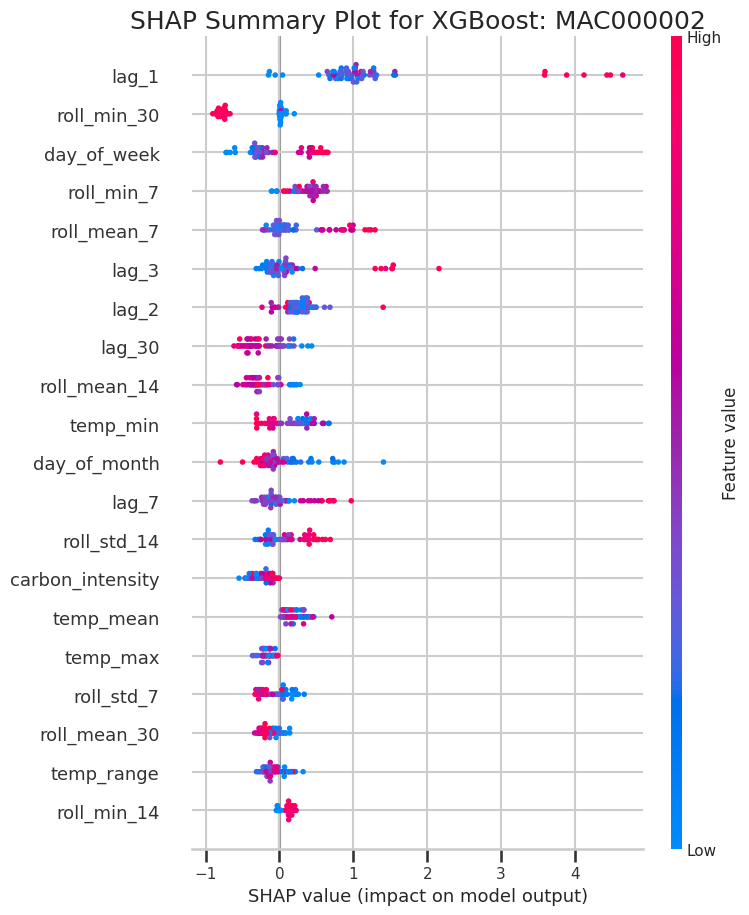

In [ ]:
house_for_xai = SELECTED_HOUSE
xgb_model = xgb_models.get(house_for_xai, None)

df_home_xgb = df_model[df_model["LCLid"] == house_for_xai].copy()
feature_cols = [c for c in df_home_xgb.columns if c not in ["LCLid", "date", "daily_kWh", "daily_kWh_log"]]

xgb_test_df = df_home_xgb[df_home_xgb["date"] >= test_start].copy()
X_test_xgb = xgb_test_df[feature_cols]

if xgb_model is not None and len(X_test_xgb) > 0:
    explainer = shap.Explainer(xgb_model)
    shap_values = explainer(X_test_xgb)

    shap.summary_plot(shap_values, X_test_xgb, show=False)
    plt.title(f"SHAP Summary Plot for XGBoost: {house_for_xai}")
    plt.tight_layout()
    plt.show()



**30.2 Permutation Importance for TCN**

In [ ]:
def tcn_permutation_importance_from_series(df_home, lookback=30, test_start=None, val_start=None, epochs=20):
    df_home = df_home.sort_values("date")[["date", "daily_kWh"]].dropna().copy()
    scaler = MinMaxScaler()
    df_home["scaled"] = scaler.fit_transform(df_home[["daily_kWh"]])

    X, y, dates = [], [], []
    series = df_home["scaled"].values
    date_vals = df_home["date"].values

    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i])
        y.append(series[i])
        dates.append(date_vals[i])

    X = np.array(X)
    y = np.array(y)
    dates = pd.to_datetime(np.array(dates))

    train_mask = dates < val_start
    val_mask = (dates >= val_start) & (dates < test_start)
    test_mask = dates >= test_start

    X_train = X[train_mask][..., np.newaxis]
    y_train = y[train_mask]
    X_test = X[test_mask][..., np.newaxis]
    y_test = y[test_mask]

    if val_mask.sum() > 0:
        X_val = X[val_mask][..., np.newaxis]
        y_val = y[val_mask]
    else:
        return None, None

    model = Sequential([
        TCN(32, dropout_rate=0.1),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=16,
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
    )

    baseline_pred = model.predict(X_test, verbose=0).flatten()
    baseline_error = mean_absolute_error(y_test, baseline_pred)

    importances = []
    feature_names = ["energy_sequence"]

    for f in range(X_test.shape[2]):
        X_perm = X_test.copy()
        np.random.shuffle(X_perm[:, :, f])
        pred = model.predict(X_perm, verbose=0).flatten()
        error = mean_absolute_error(y_test, pred)
        importances.append(error - baseline_error)

    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    return imp_df, model

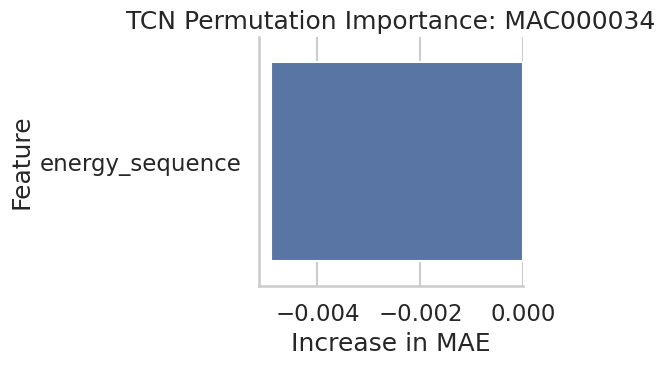

In [ ]:
perm_df, _ = tcn_permutation_importance_from_series(
merged2[merged2["LCLid"] == SELECTED_HOUSE].copy(),
    lookback=30,
    test_start=test_start,
    val_start=val_start,
    epochs=10
)

if perm_df is not None:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=perm_df, x="importance", y="feature")
    plt.title(f"TCN Permutation Importance: {best_house}")
    plt.xlabel("Increase in MAE")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## **31. Carbon Impact Analysis**

### **31.1 Carbon Impact for STL Residuals**

In [ ]:
carbon_records = []

for hid, home_test in stl_details.items():
    temp = compute_excess_carbon(home_test, residual_col="residual_test")
    carbon_records.append({
        "LCLid": hid,
        "excess_energy_kwh": temp["positive_residual"].sum(),
        "excess_carbon_g": temp["excess_carbon_g"].sum()
    })

carbon_summary = pd.DataFrame(carbon_records).sort_values("excess_carbon_g", ascending=False)
carbon_summary.head(10)

,LCLid,excess_energy_kwh,excess_carbon_g
1,MAC000003,314.059,"147,457.199"
16,MAC000024,181.116,"82,840.258"
25,MAC000035,174.012,"80,244.066"
13,MAC000021,134.459,"61,626.411"
18,MAC000026,123.966,"56,717.396"
21,MAC000030,126.526,"55,422.088"
15,MAC000023,113.383,"51,613.814"
30,MAC000040,109.645,"50,973.164"
24,MAC000034,111.815,"49,283.908"
28,MAC000038,104.729,"47,643.110"


### **31.2 Energy Drift vs Carbon Drift for Showcase Household**

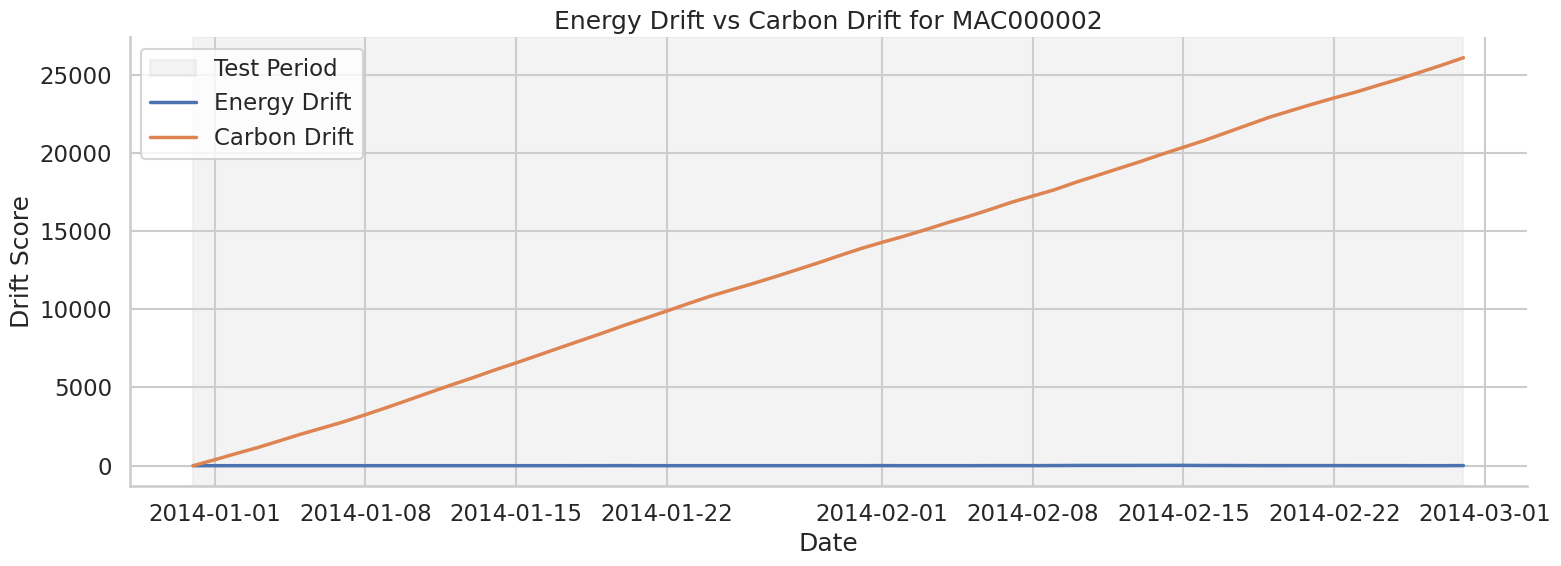

In [ ]:
if "carbon_intensity" in merged2.columns:
    # Use SELECTED_HOUSE directly or assign it to 'house'
    house_id_for_plot = SELECTED_HOUSE
    carbon_df = merged2[merged2["LCLid"] == house_id_for_plot][["date", "carbon_intensity"]].copy()
    carbon_df = carbon_df[carbon_df["date"] >= test_start].dropna()

    c = carbon_df["carbon_intensity"].fillna(0).values
    carbon_cusum_pos, _, _, _, _ = cusum_drift(c)

    carbon_plot_df = pd.DataFrame({
        "date": carbon_df["date"].values,
        "carbon_drift": carbon_cusum_pos
    })

    # Retrieve stl_test from the results dictionary
    if results and "stl_test" in results:
        stl_df = results["stl_test"]
    else:
        print("STL test results not available for carbon comparison.")
        stl_df = pd.DataFrame() # Create an empty DataFrame to prevent further errors

    if not stl_df.empty and "cusum_neg" in stl_df.columns:
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.axvspan(test_start, stl_df["date"].max(), color="lightgrey", alpha=0.25, label="Test Period")

        sns.lineplot(x=stl_df["date"], y=stl_df["cusum_neg"].abs(), ax=ax, label="Energy Drift", linewidth=2.5)
        sns.lineplot(data=carbon_plot_df, x="date", y="carbon_drift", ax=ax, label="Carbon Drift", linewidth=2.5)

        ax.set_title(f"Energy Drift vs Carbon Drift for {house_id_for_plot}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Drift Score")
        ax.legend(frameon=True)
        plt.tight_layout()
        plt.show()
    else:
        print("Cannot plot carbon comparison: STL test results or cusum_neg column missing.")


## **32. Dashboard-Ready Export Files**

In [ ]:
os.makedirs("outputs", exist_ok=True)

comparison.to_csv("outputs/comparison_summary.csv", index=False)
early_eval.to_csv("outputs/early_detection_eval.csv", index=False)
carbon_summary.to_csv("outputs/carbon_summary.csv", index=False)

if results["stl_test"] is not None:
    results["stl_test"].to_csv(f"outputs/{SELECTED_HOUSE}_stl_detail.csv", index=False)

if results["tcn_pred_df"] is not None:
    results["tcn_pred_df"].to_csv(f"outputs/{SELECTED_HOUSE}_tcn_detail.csv", index=False)

if results["xgb_pred_df"] is not None:
    results["xgb_pred_df"].to_csv(f"outputs/{SELECTED_HOUSE}_xgb_detail.csv", index=False)

house_summary.to_csv(f"outputs/{SELECTED_HOUSE}_summary.csv", index=False)
print("Dashboard-ready files exported.")

Dashboard-ready files exported.


## **33. Minimal Streamlit App Prototype**

2026-04-11 15:34:24.975 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 15:34:24.976 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 15:34:25.756 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-11 15:34:25.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 15:34:25.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 15:34:25.764 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-11 15:34:25.764 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

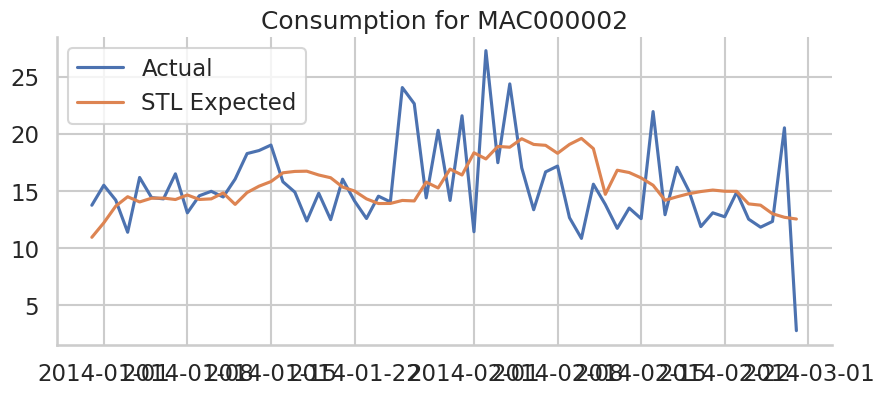

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Energy Drift Dashboard", layout="wide")
st.title("Household Energy Drift Detection Dashboard")

comparison = pd.read_csv("outputs/comparison_summary.csv")
carbon_summary = pd.read_csv("outputs/carbon_summary.csv")

households = comparison["LCLid"].dropna().unique().tolist()
selected_house = st.selectbox("Select Household", households)

st.subheader("Comparison Summary")
st.dataframe(comparison[comparison["LCLid"] == selected_house])

st.subheader("Top Carbon Impact Households")
st.dataframe(carbon_summary.head(10))

try:
    stl_df = pd.read_csv(f"outputs/{selected_house}_stl_detail.csv")
    stl_df["date"] = pd.to_datetime(stl_df["date"])

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(stl_df["date"], stl_df["daily_kWh"], label="Actual")
    if "expected_test" in stl_df.columns:
        ax.plot(stl_df["date"], stl_df["expected_test"], label="STL Expected")
    ax.legend()
    ax.set_title(f"Consumption for {selected_house}")
    st.pyplot(fig)
except:
    st.info("Detailed STL file not found for this household.")